# Prevendo preço de carros

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
df = pd.read_csv('carprices.csv')

In [6]:
df

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


In [7]:
df.dtypes

Car Model        object
Mileage           int64
Sell Price($)     int64
Age(yrs)          int64
dtype: object

In [8]:
df.shape

(13, 4)

In [9]:
df.isnull().values.any()

False

In [10]:
# Verificando se existe uma correlação

def plot_corr(df, size=10):
    corr = df.corr()
    fig, ax = plt.subplots(figsize= (size, size))
    ax.matshow(corr)
    plt.xticks(range(len(corr.columns)), corr.columns)
    plt.yticks(range(len(corr.columns)), corr.columns)

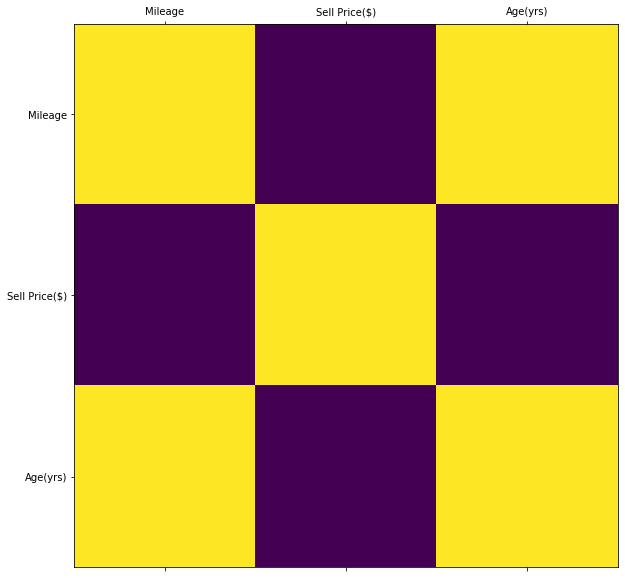

In [11]:
plot_corr(df)

In [13]:
df.corr()

,Mileage,Sell Price($),Age(yrs)
Mileage,1.000000,-0.927116,0.993452
Sell Price($),-0.927116,1.000000,-0.921741
Age(yrs),0.993452,-0.921741,1.000000


In [15]:
# vamos organizar as variáveis que são categóricas - marcas

df_dummies = pd.get_dummies(df['Car Model'])

In [16]:
df_dummies

,Audi A5,BMW X5,Mercedez Benz C class
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0
5,1,0,0
6,1,0,0
7,1,0,0
8,1,0,0
9,0,0,1


In [18]:
df_numerical = df[['Mileage', 'Age(yrs)', 'Sell Price($)']]
df_numerical

,Mileage,Age(yrs),Sell Price($)
0,69000,6,18000
1,35000,3,34000
2,57000,5,26100
3,22500,2,40000
4,46000,4,31500
5,59000,5,29400
6,52000,5,32000
7,72000,6,19300
8,91000,8,12000
9,67000,6,22000


In [19]:
df_new = pd.concat([df_dummies, df_numerical], axis=1)

In [20]:
df_new

,Audi A5,BMW X5,Mercedez Benz C class,Mileage,Age(yrs),Sell Price($)
0,0,1,0,69000,6,18000
1,0,1,0,35000,3,34000
2,0,1,0,57000,5,26100
3,0,1,0,22500,2,40000
4,0,1,0,46000,4,31500
5,1,0,0,59000,5,29400
6,1,0,0,52000,5,32000
7,1,0,0,72000,6,19300
8,1,0,0,91000,8,12000
9,0,0,1,67000,6,22000


In [21]:
df_new.dtypes

Audi A5                  uint8
BMW X5                   uint8
Mercedez Benz C class    uint8
Mileage                  int64
Age(yrs)                 int64
Sell Price($)            int64
dtype: object

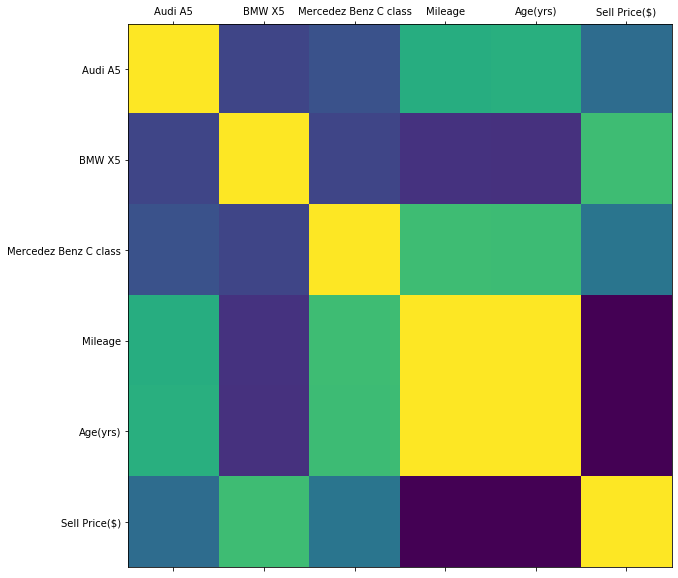

In [22]:
plot_corr(df_new)

In [23]:
df_new.corr()

,Audi A5,BMW X5,Mercedez Benz C class,Mileage,Age(yrs),Sell Price($)
Audi A5,1.000000,-0.527046,-0.444444,0.275426,0.290701,-0.246918
BMW X5,-0.527046,1.000000,-0.527046,-0.642673,-0.651155,0.400640
Mercedez Benz C class,-0.444444,-0.527046,1.000000,0.402011,0.395676,-0.175394
Mileage,0.275426,-0.642673,0.402011,1.000000,0.993452,-0.927116
Age(yrs),0.290701,-0.651155,0.395676,0.993452,1.000000,-0.921741
Sell Price($),-0.246918,0.400640,-0.175394,-0.927116,-0.921741,1.000000


In [25]:
# agora percebi que o modelo inflencia - moderadamente - no preço de venda

# com isso vou definir as variáveis do processo

features = ['Audi A5', 'BMW X5', 'Mercedez Benz C class', 'Mileage', 'Age(yrs)']

target = ['Sell Price($)']

In [26]:
# agora vou dividir os dados e aplicar o modelo de ML

X = df_new[features].values

y = df_new[target].values

In [27]:
X

array([[    0,     1,     0, 69000,     6],
       [    0,     1,     0, 35000,     3],
       [    0,     1,     0, 57000,     5],
       [    0,     1,     0, 22500,     2],
       [    0,     1,     0, 46000,     4],
       [    1,     0,     0, 59000,     5],
       [    1,     0,     0, 52000,     5],
       [    1,     0,     0, 72000,     6],
       [    1,     0,     0, 91000,     8],
       [    0,     0,     1, 67000,     6],
       [    0,     0,     1, 83000,     7],
       [    0,     0,     1, 79000,     7],
       [    0,     0,     1, 59000,     5]], dtype=int64)

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)

In [37]:
X_test

array([[    0,     1,     0, 22500,     2],
       [    1,     0,     0, 72000,     6],
       [    0,     0,     1, 79000,     7],
       [    1,     0,     0, 52000,     5]], dtype=int64)

In [38]:
# vou aplicar o modelo de Regressão linear

from sklearn.linear_model import LinearRegression

In [39]:
lr_model = LinearRegression()

In [40]:
lr_model.fit(X_train, y_train.ravel())

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [41]:
lr_model.predict(X_test)

array([40759.91989318, 25418.50467291, 17956.58210947, 24802.42990655])

In [42]:
# respondendo Perguntas de negócio

# 1 prever o preço de um mercedez C class com 4 anos e 45000 de quilometragem

lr_model.predict([[0,0,1,45000,4]])

array([34778.37116154])

In [43]:
lr_model.predict([[0,1,0,86000,7]])

array([17630.46728973])

In [45]:
lr_model.score(X,y)

0.8498848486865707